"""
=============================================================================
SHAP Analysis Test with WagePanel Data
=============================================================================

This script demonstrates SHAP interpretability analysis using WagePanel data:
1. Load WagePanel dataset (classic wage panel data)
2. Train PanelEnsembleXGBoost model
3. Generate SHAP visualizations:
   - Bar plot (feature importance)
   - Beeswarm plot (SHAP value distribution)
   - Partial dependence plots for all features
   - Waterfall plots for individual predictions

Author: PanelEnsembleXGBoost Research Team
=============================================================================
"""

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from panel_ensemble_xgboost import PanelEnsembleXGBoost
from shap_analyzer import SHAPAnalyzer


def load_wage_panel_data():
    """
    Load WagePanel dataset
    
    The WagePanel dataset is a classic panel dataset containing:
    - Individual wage data over multiple years
    - Education, experience, marriage status, etc.
    - Suitable for panel data analysis
    
    Returns
    -------
    pd.DataFrame
        WagePanel dataset
    """
    try:
        # Try to load from linearmodels
        from linearmodels.datasets import wage_panel
        
        df = wage_panel.load()
        
        print("\n" + "=" * 70)
        print("WagePanel Dataset Summary (from linearmodels)")
        print("=" * 70)
        print(f"Total observations: {len(df)}")
        print(f"Number of individuals: {df.index.get_level_values(0).nunique()}")
        print(f"Number of years: {df.index.get_level_values(1).nunique()}")
        print(f"\nColumns: {list(df.columns)}")
        print(f"\nDescriptive statistics:\n{df.describe()}")
        
        return df
        
    except ImportError:
        print("Warning: linearmodels not installed. Trying alternative method...")
        return load_wage_panel_alternative()
    except Exception as e:
        print(f"Warning: Could not load WagePanel from linearmodels: {e}")
        return load_wage_panel_alternative()


def load_wage_panel_alternative():
    """
    Alternative method to load WagePanel from statsmodels or generate synthetic data
    """
    try:
        import statsmodels.api as sm
        
        # Load from statsmodels
        data = sm.datasets.get_rdataset("Panel", "plm", cache=True)
        df = data.data
        
        # Rename columns to standard format
        df = df.rename(columns={
            'nr': 'ID',
            'year': 'year',
            'lwage': 'y',  # log wage
            'exp': 'exper',
            'exp2': 'exper_sq',
            'wks': 'weeks',
            'union': 'union',
            'ed': 'education',
            'south': 'south',
            'married': 'married',
            'black': 'black',
            'occ': 'occupation',
            'ind': 'industry'
        })
        
        print("\n" + "=" * 70)
        print("WagePanel Dataset Summary (from statsmodels)")
        print("=" * 70)
        print(f"Total observations: {len(df)}")
        print(f"Number of individuals: {df['ID'].nunique()}")
        print(f"Number of years: {df['year'].nunique()}")
        
        return df
        
    except Exception as e:
        print(f"Warning: Could not load WagePanel from statsmodels: {e}")
        print("Generating synthetic WagePanel-like data...")
        return generate_synthetic_wage_panel()


def generate_synthetic_wage_panel(n_units=300, n_periods=10, seed=42):
    """
    Generate synthetic WagePanel-like data as fallback
    """
    np.random.seed(seed)
    
    print("\n" + "=" * 70)
    print("Generating Synthetic WagePanel-like Data")
    print("=" * 70)
    
    # Create regional grouping for random effects
    n_regions = 20
    region_effects = {r: np.random.normal(0, 0.15) for r in range(n_regions)}
    
    data = []
    
    for unit in range(n_units):
        # Assign each individual to a region
        region = unit % n_regions
        region_effect = region_effects[region]
        
        # Individual characteristics (time-invariant)
        education = np.random.choice([12, 14, 16, 18], p=[0.3, 0.3, 0.25, 0.15])
        black = np.random.binomial(1, 0.2)
        hispanic = np.random.binomial(1, 0.1) if black == 0 else 0
        
        # Base experience for this individual
        base_experience = np.random.randint(0, 15)
        
        for period in range(n_periods):
            # Time-varying characteristics
            experience = base_experience + period
            experience_sq = experience ** 2
            
            weeks = 48 + np.random.randint(-5, 5)
            married_prob = min(0.6 + 0.03 * period, 0.95)
            married = np.random.binomial(1, married_prob)
            union = np.random.binomial(1, 0.2)
            south = np.random.binomial(1, 0.3)
            
            # Log wage generation
            base_wage = 6.0
            education_effect = 0.08 * education
            experience_effect = 0.05 * experience - 0.001 * experience_sq
            weeks_effect = 0.01 * weeks
            married_effect = 0.15 * married
            union_effect = 0.10 * union
            south_effect = -0.10 * south
            black_effect = -0.15 * black
            
            time_trend = 0.02 * period
            individual_fe = np.random.normal(0, 0.3)
            noise = np.random.normal(0, 0.25)
            
            # Include region effect in wage
            lwage = (base_wage + education_effect + experience_effect + 
                    weeks_effect + married_effect + union_effect + 
                    south_effect + black_effect + time_trend + 
                    individual_fe + region_effect + noise)
            
            data.append({
                'ID': unit,
                'year': 1980 + period,
                'region': f'Region_{region}',
                'y': lwage,
                'education': education,
                'exper': experience,
                'exper_sq': experience_sq,
                'weeks': weeks,
                'married': married,
                'union': union,
                'south': south,
                'black': black,
                'hispanic': hispanic
            })
    
    df = pd.DataFrame(data)
    
    print(f"Generated observations: {len(df)}")
    print(f"Number of individuals: {df['ID'].nunique()}")
    print(f"Number of years: {df['year'].nunique()}")
    print(f"Number of regions: {df['region'].nunique()} (for random effects)")
    
    return df


def train_model(df):
    """
    Train PanelEnsembleXGBoost model with WagePanel data
    
    Parameters
    ----------
    df : pd.DataFrame
        WagePanel dataset
        
    Returns
    -------
    model : PanelEnsembleXGBoost
        Trained model
    X : pd.DataFrame
        Feature matrix
    y : np.array
        Target values
    groups : pd.DataFrame
        Grouping variable for random effects
    feature_cols : list
        Feature column names
    """
    print("\n" + "=" * 70)
    print("PanelEnsembleXGBoost Model Training")
    print("=" * 70)
    
    # Prepare features
    print("\n[1. Prepare Features]")
    
    df_work = df.copy()
    
    # Check if data has index structure
    if hasattr(df_work.index, 'names') and df_work.index.names == ['nr', 'year']:
        df_work = df_work.reset_index()
        if 'nr' in df_work.columns:
            df_work = df_work.rename(columns={'nr': 'ID'})
    
    # Define feature columns based on available data
    potential_features = ['education', 'exper', 'exper_sq', 'weeks', 
                         'married', 'union', 'south', 'black', 'hispanic']
    
    feature_cols = [c for c in potential_features if c in df_work.columns]
    
    # Ensure ID and year columns exist
    if 'ID' not in df_work.columns:
        if hasattr(df_work.index, 'levels'):
            df_work['ID'] = df_work.index.get_level_values(0)
        else:
            df_work['ID'] = range(len(df_work))
    
    if 'year' not in df_work.columns:
        if hasattr(df_work.index, 'levels'):
            df_work['year'] = df_work.index.get_level_values(1)
        else:
            df_work['year'] = 0
    
    # Set target variable (log wage)
    if 'y' not in df_work.columns:
        if 'lwage' in df_work.columns:
            df_work['y'] = df_work['lwage']
        elif 'wage' in df_work.columns:
            df_work['y'] = np.log(df_work['wage'] + 1)
        else:
            raise ValueError("No wage/outcome column found")
    
    X = df_work[feature_cols + ['ID', 'year']].copy()
    y = df_work['y'].values
    
    # Check for grouping variable
    group_name = None
    groups = None
    
    # Use meaningful grouping variables with appropriate group count
    for group_var in ['region', 'industry', 'occupation']:
        if group_var in df_work.columns:
            n_groups = df_work[group_var].nunique()
            if 5 <= n_groups <= 100:  # Ideal range for random effects
                groups = df_work[[group_var]].copy()
                group_name = group_var
                print(f"  ✓ Using '{group_var}' as random effects group ({n_groups} groups)")
                break
            elif n_groups > 100:
                print(f"  Note: '{group_var}' has {n_groups} groups, too many for random effects")
    
    if group_name is None:
        print(f"  No suitable grouping variable found, random effects will be disabled")
    
    # Determine smooth terms based on features
    smooth_terms = {}
    if 'exper' in feature_cols:
        smooth_terms['exper'] = 'gam'  # Experience has nonlinear effect on wage
    if 'education' in feature_cols:
        smooth_terms['education'] = 'gam'  # Education may have diminishing returns
    if 'weeks' in feature_cols:
        smooth_terms['weeks'] = 'gam'  # Weeks worked may have threshold effect
    
    # Create model
    print("\n[2. Create PanelEnsembleXGBoost Model]")
    
    if group_name is not None:
        print(f"    Stage 1: Random Effects (grouping by '{group_name}')")
    else:
        print(f"    Stage 1: Random Effects (none)")
    
    if smooth_terms:
        print(f"    Stage 2: GAM Smooth Effects ({list(smooth_terms.keys())})")
    
    print(f"    Stage 3: XGBoost Interaction Effects")
    
    # Prepare random effects groups parameter
    random_effects_groups_param = [group_name] if group_name is not None else None
    
    model = PanelEnsembleXGBoost(
        random_effects_groups=random_effects_groups_param,
        smooth_terms=smooth_terms,
        xgb_params={
            'n_estimators': 300,
            'max_depth': 5,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'verbosity': 0
        },
        verbose=True
    )
    
    # Fit model
    print("\n[3. Fit Model]")
    model.fit(X, y, groups_for_random_effects=groups)
    
    # Predict
    print("\n[4. Model Prediction]")
    y_pred = model.predict(X, groups_for_random_effects=groups)
    
    # Evaluate
    mse = np.mean((y - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y - y_pred))
    r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
    
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    
    return model, X, y, groups, feature_cols


def shap_analysis(model, X, y, groups, feature_cols, output_dir=None):
    """
    Perform SHAP analysis and generate visualizations
    
    Parameters
    ----------
    model : PanelEnsembleXGBoost
        Trained model
    X : pd.DataFrame
        Feature matrix
    y : np.array
        Target values
    groups : pd.DataFrame
        Grouping variable for random effects
    feature_cols : list
        Feature column names
    output_dir : str, optional
        Output directory for saving plots
        
    Returns
    -------
    analyzer : SHAPAnalyzer
        SHAP analyzer object
    importance_df : pd.DataFrame
        Feature importance dataframe
    """
    print("\n" + "=" * 70)
    print("SHAP Analysis with WagePanel Data")
    print("=" * 70)
    
    try:
        import shap
    except ImportError:
        print("SHAP package not installed, skipping analysis")
        print("Installation command: pip install shap")
        return None, None
    
    # Prepare data for SHAP analysis
    print("\n[1. Prepare Data for SHAP Analysis]")
    
    # Use subset of data for faster computation
    n_samples = min(100, len(X))
    X_sample = X.head(n_samples).copy()
    groups_sample = groups.head(n_samples).copy() if groups is not None else None
    
    # Filter to only feature columns (exclude ID and year)
    feature_cols_filtered = [col for col in feature_cols if col in X_sample.columns]
    X_features = X_sample[feature_cols_filtered]
    
    print(f"  Sample size: {n_samples}")
    print(f"  Features for SHAP: {feature_cols_filtered}")
    
    # Create prediction wrapper for SHAP
    print("\n[2. Create Prediction Wrapper]")
    
    if groups_sample is not None:
        def predict_wrapper(x):
            """Wrapper to handle groups parameter for SHAP"""
            if isinstance(x, np.ndarray):
                x_df = pd.DataFrame(x, columns=feature_cols_filtered)
            else:
                x_df = x.copy() if isinstance(x, pd.DataFrame) else pd.DataFrame(x, columns=feature_cols_filtered)
            
            # Add ID and year columns (use defaults)
            x_full = x_df.copy()
            x_full['ID'] = 0
            x_full['year'] = 0
            
            # Match groups length
            if len(x_full) <= len(groups_sample):
                groups_for_pred = groups_sample.iloc[:len(x_full)]
            else:
                repeat_factor = (len(x_full) + len(groups_sample) - 1) // len(groups_sample)
                groups_for_pred = pd.concat([groups_sample] * repeat_factor, ignore_index=True).iloc[:len(x_full)]
            
            return model.predict(x_full, groups_for_random_effects=groups_for_pred)
    else:
        def predict_wrapper(x):
            if isinstance(x, np.ndarray):
                x_df = pd.DataFrame(x, columns=feature_cols_filtered)
            else:
                x_df = x.copy() if isinstance(x, pd.DataFrame) else pd.DataFrame(x, columns=feature_cols_filtered)
            x_full = x_df.copy()
            x_full['ID'] = 0
            x_full['year'] = 0
            return model.predict(x_full)
    
    # Create SHAP analyzer
    print("\n[3. Initialize SHAP Analyzer]")
    analyzer = SHAPAnalyzer(
        predict_fn=predict_wrapper,
        X_background=X_features.head(min(50, len(X_features))),
        feature_names=feature_cols_filtered
    )
    
    # Compute SHAP values
    print("\n[4. Compute SHAP Values]")
    print("  Using KernelExplainer (model-agnostic)...")
    shap_values = analyzer.compute_shap_values(X_features)
    print(f"  SHAP values shape: {shap_values.shape}")
    
    # Set output directory
    if output_dir is None:
        output_dir = current_dir
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # =========================================================================
    # Visualization 1: Feature Importance Bar Plot
    # =========================================================================
    print("\n[5. Visualization 1: Feature Importance Bar Plot]")
    print("  Creating feature importance bar plot...")
    
    importance_df = analyzer.get_feature_importance()
    print("\n  Feature Importance Ranking:")
    print(importance_df.to_string(index=False))
    
    analyzer.plot_feature_importance(
        save_path=os.path.join(output_dir, 'wage_shap_bar.png')
    )
    print(f"  Saved: wage_shap_bar.png")
    
    # =========================================================================
    # Visualization 2: Summary Plot (Beeswarm)
    # =========================================================================
    print("\n[6. Visualization 2: Beeswarm Plot]")
    print("  Creating beeswarm summary plot...")
    print("  This shows SHAP value distribution for each feature")
    
    analyzer.plot_summary(
        plot_type='beeswarm',
        save_path=os.path.join(output_dir, 'wage_shap_beeswarm.png')
    )
    print(f"  Saved: wage_shap_beeswarm.png")
    
    # =========================================================================
    # Visualization 3: Partial Dependence Plots for All Features
    # =========================================================================
    print("\n[7. Visualization 3: Partial Dependence Plots]")
    print("  Creating partial dependence plots for all features...")
    print("  These show the average effect of each feature on model predictions")
    
    analyzer.plot_partial_dependence(
        save_path=os.path.join(output_dir, 'wage_shap_partial_dependence.png')
    )
    print(f"  Saved: wage_shap_partial_dependence.png")
    
    # =========================================================================
    # Visualization 4: Waterfall Plots (Combined)
    # =========================================================================
    print("\n[8. Visualization 4: Waterfall Plots (Combined)]")
    print("  Creating combined waterfall plots for first 4 instances...")
    
    import shap
    
    n_waterfall = min(4, len(X_features))
    fig_waterfall, axes_waterfall = plt.subplots(2, 2, figsize=(16, 14))
    axes_waterfall = axes_waterfall.flatten()
    
    for i, idx in enumerate(range(n_waterfall)):
        plt.sca(axes_waterfall[i])
        
        X_inst = X_features.iloc[[idx]]
        shap_val = analyzer.shap_values[[idx]]
        
        # Create SHAP Explanation object
        explanation = shap.Explanation(
            values=shap_val[0],
            base_values=analyzer.expected_value,
            data=X_inst.iloc[0],
            feature_names=feature_cols_filtered
        )
        
        # Use waterfall plot on the specific axes
        shap.waterfall_plot(explanation, max_display=10, show=False)
        axes_waterfall[i].set_title(f'Instance {idx}', fontsize=10, fontweight='bold')
    
    # Hide any unused subplots
    for i in range(n_waterfall, 4):
        axes_waterfall[i].axis('off')
    
    plt.suptitle('SHAP Waterfall Plots (Combined)', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'wage_shap_waterfall_combined.png'), dpi=600, bbox_inches='tight')
    print(f"  Saved: wage_shap_waterfall_combined.png")
    plt.close()
    
    # Also save individual waterfall plots
    for idx in range(n_waterfall):
        analyzer.plot_waterfall(
            instance_idx=idx,
            save_path=os.path.join(output_dir, f'wage_shap_waterfall_instance{idx}.png')
        )
    
    # =========================================================================
    # Visualization 5: Combined Summary Figure (All Visualizations)
    # =========================================================================
    print("\n[9. Creating Combined Summary Figure]")
    print("  Combining all SHAP visualizations into one comprehensive figure...")
    
    from PIL import Image, ImageDraw, ImageFont
    
    # Load all saved images
    img_bar = Image.open(os.path.join(output_dir, 'wage_shap_bar.png'))
    img_beeswarm = Image.open(os.path.join(output_dir, 'wage_shap_beeswarm.png'))
    img_pdp = Image.open(os.path.join(output_dir, 'wage_shap_partial_dependence.png'))
    img_waterfall = Image.open(os.path.join(output_dir, 'wage_shap_waterfall_combined.png'))
    
    # Get dimensions
    bar_w, bar_h = img_bar.size
    beeswarm_w, beeswarm_h = img_beeswarm.size
    pdp_w, pdp_h = img_pdp.size
    waterfall_w, waterfall_h = img_waterfall.size
    
    # Calculate the combined figure size
    # Layout: 2x2 grid
    # Top row: Feature Importance Bar + Beeswarm
    # Bottom row: Partial Dependence + Waterfall
    
    # Resize images to have consistent heights within each row
    # Row 1: Bar and Beeswarm should have same height
    row1_height = max(bar_h, beeswarm_h)
    bar_scale = row1_height / bar_h
    beeswarm_scale = row1_height / beeswarm_h
    
    bar_new_w = int(bar_w * bar_scale)
    beeswarm_new_w = int(beeswarm_w * beeswarm_scale)
    
    img_bar_resized = img_bar.resize((bar_new_w, row1_height), Image.Resampling.LANCZOS)
    img_beeswarm_resized = img_beeswarm.resize((beeswarm_new_w, row1_height), Image.Resampling.LANCZOS)
    
    # Row 2: PDP and Waterfall should have same height
    row2_height = max(pdp_h, waterfall_h)
    pdp_scale = row2_height / pdp_h
    waterfall_scale = row2_height / waterfall_h
    
    pdp_new_w = int(pdp_w * pdp_scale)
    waterfall_new_w = int(waterfall_w * waterfall_scale)
    
    img_pdp_resized = img_pdp.resize((pdp_new_w, row2_height), Image.Resampling.LANCZOS)
    img_waterfall_resized = img_waterfall.resize((waterfall_new_w, row2_height), Image.Resampling.LANCZOS)
    
    # Calculate combined figure dimensions
    row1_width = bar_new_w + beeswarm_new_w
    row2_width = pdp_new_w + waterfall_new_w
    total_width = max(row1_width, row2_width)
    total_height = row1_height + row2_height
    
    # Create blank canvas with white background
    combined_img = Image.new('RGB', (total_width, total_height), 'white')
    
    # Calculate positions for centering
    row1_x_offset = (total_width - row1_width) // 2
    row2_x_offset = (total_width - row2_width) // 2
    
    # Paste images
    combined_img.paste(img_bar_resized, (row1_x_offset, 0))
    combined_img.paste(img_beeswarm_resized, (row1_x_offset + bar_new_w, 0))
    combined_img.paste(img_pdp_resized, (row2_x_offset, row1_height))
    combined_img.paste(img_waterfall_resized, (row2_x_offset + pdp_new_w, row1_height))
    
    # Add labels (a), (b), (c), (d) to each subplot
    draw = ImageDraw.Draw(combined_img)
    
    # Try to use a font, fallback to default if not available
    font_size = max(60, int(min(total_width, total_height) * 0.025))
    try:
        # Try common fonts
        font_paths = [
            "C:/Windows/Fonts/arial.ttf",
            "C:/Windows/Fonts/times.ttf",
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            "/System/Library/Fonts/Helvetica.ttc"
        ]
        font = None
        for font_path in font_paths:
            try:
                font = ImageFont.truetype(font_path, font_size)
                break
            except:
                continue
        if font is None:
            font = ImageFont.load_default()
    except:
        font = ImageFont.load_default()
    
    # Label positions (with padding)
    label_padding = 20
    labels = ['(a)', '(b)', '(c)', '(d)']
    
    # Calculate positions for each label
    positions = [
        (row1_x_offset + label_padding, label_padding),  # (a) for Bar plot
        (row1_x_offset + bar_new_w + label_padding, label_padding),  # (b) for Beeswarm
        (row2_x_offset + label_padding, row1_height + label_padding),  # (c) for PDP
        (row2_x_offset + pdp_new_w + label_padding, row1_height + label_padding),  # (d) for Waterfall
    ]
    
    # Draw labels with white background for visibility
    for label, (x, y) in zip(labels, positions):
        # Get text bounding box
        bbox = draw.textbbox((x, y), label, font=font)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]
        
        # Draw white background rectangle
        draw.rectangle([x - 5, y - 5, x + text_w + 5, y + text_h + 5], fill='white')
        
        # Draw text
        draw.text((x, y), label, fill='black', font=font)
    
    # Save combined image
    combined_path = os.path.join(output_dir, 'wage_shap_combined_summary.png')
    combined_img.save(combined_path, quality=95, dpi=(600, 600))
    print(f"  Saved: wage_shap_combined_summary.png")
    print(f"  Combined image size: {total_width} x {total_height} pixels")
    
    # =========================================================================
    # Summary
    # =========================================================================
    print("\n" + "=" * 70)
    print("SHAP Analysis Summary")
    print("=" * 70)
    
    print("\n[Feature Importance Interpretation]")
    for i, row in importance_df.iterrows():
        feature = row['feature']
        importance = row['importance']
        
        print(f"\n{i+1}. {feature}:")
        print(f"   Mean |SHAP|: {importance:.4f}")
        
        # Interpret feature based on WagePanel context
        interpretations = {
            'education': [
                "Education level (years of schooling)",
                "Higher education strongly increases wage",
                "Effect may be nonlinear (diminishing returns at high levels)"
            ],
            'exper': [
                "Work experience (years)",
                "Experience increases wage with diminishing returns",
                "GAM captures the nonlinear experience-wage profile"
            ],
            'weeks': [
                "Weeks worked in year",
                "More weeks worked leads to higher annual wage",
                "May have threshold effects"
            ],
            'married': [
                "Marriage status indicator",
                "Married individuals tend to have higher wages",
                "Could reflect selection or productivity effects"
            ],
            'union': [
                "Union membership indicator",
                "Union members typically have higher wages",
                "Captures collective bargaining effect"
            ],
            'south': [
                "Southern region indicator",
                "Southern location associated with lower wages",
                "Regional wage differential captured as random effect"
            ],
            'black': [
                "Race indicator (Black)",
                "Captures wage disparities by race",
                "Important for understanding wage inequality"
            ],
            'hispanic': [
                "Ethnicity indicator (Hispanic)",
                "Another demographic factor affecting wages",
                "Part of comprehensive wage analysis"
            ]
        }
        
        if feature in interpretations:
            for interp_line in interpretations[feature]:
                print(f"   {interp_line}")
        else:
            print(f"   Feature: {feature}")
            print(f"   Contribution to wage prediction: {importance:.4f}")
    
    print("\n[Generated Visualizations]")
    print("  1. wage_shap_bar.png - Feature importance bar plot")
    print("  2. wage_shap_beeswarm.png - Beeswarm plot showing SHAP distribution")
    print("  3. wage_shap_partial_dependence.png - Partial dependence plots for all features")
    print("  4. wage_shap_waterfall_combined.png - Combined waterfall plots (4 instances)")
    print("  5. wage_shap_waterfall_instance*.png - Individual waterfall plots")
    print("  6. wage_shap_combined_summary.png - Combined summary figure (all visualizations)")
    
    return analyzer, importance_df


SHAP Analysis Test with WagePanel Data

This script demonstrates:
  1. WagePanel data loading and preprocessing
  2. PanelEnsembleXGBoost model training
  3. SHAP analysis with visualizations:
     - Bar plot (feature importance)
     - Beeswarm plot
     - Partial dependence plots
     - Waterfall plots

Step 1: Load WagePanel Data

WagePanel Dataset Summary (from linearmodels)
Total observations: 4360
Number of individuals: 4360
Generating synthetic WagePanel-like data...

Generating Synthetic WagePanel-like Data
Generated observations: 3000
Number of individuals: 300
Number of years: 10
Number of regions: 20 (for random effects)

PanelEnsembleXGBoost Model Training

[1. Prepare Features]
  ✓ Using 'region' as random effects group (20 groups)

[2. Create PanelEnsembleXGBoost Model]
    Stage 1: Random Effects (grouping by 'region')
    Stage 2: GAM Smooth Effects (['exper', 'education', 'weeks'])
    Stage 3: XGBoost Interaction Effects

[3. Fit Model]

[Fitting PanelEnsembleXGBoost

  0%|          | 0/100 [00:00<?, ?it/s]

  Random effects prediction statistics: mean=8.1594, std=0.0000, range=[8.1594, 8.1594]
  Stage 2 prediction statistics: mean=-0.0131, std=0.0000, range=[-0.0131, -0.0131]
  XGBoost prediction using 12/12 features
  Stage 3 prediction statistics: mean=0.0631, std=0.0000, range=[0.0631, 0.0631]
  Random effects prediction statistics: mean=8.1804, std=0.1998, range=[7.6256, 8.7881]
  Stage 2 prediction statistics: mean=-0.0050, std=0.0108, range=[-0.0155, 0.0261]
  XGBoost prediction using 12/12 features
  Stage 3 prediction statistics: mean=0.0262, std=0.1177, range=[-0.5018, 0.3256]
  Random effects prediction statistics: mean=8.2029, std=0.0000, range=[8.2029, 8.2029]
  Stage 2 prediction statistics: mean=-0.0110, std=0.0000, range=[-0.0110, -0.0110]
  XGBoost prediction using 12/12 features
  Stage 3 prediction statistics: mean=0.3256, std=0.0000, range=[0.3256, 0.3256]
  Random effects prediction statistics: mean=8.2021, std=0.1884, range=[7.6722, 8.7850]
  Stage 2 prediction statis

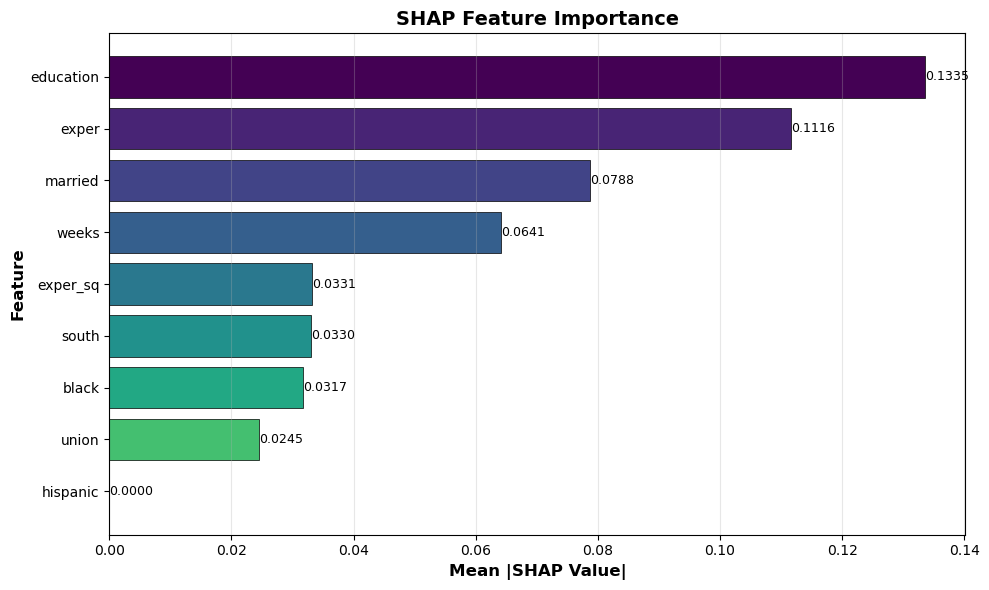

  Saved: wage_shap_bar.png

[6. Visualization 2: Beeswarm Plot]
  Creating beeswarm summary plot...
  This shows SHAP value distribution for each feature
Saved beeswarm plot to f:\空间统计与计量方法\文章发表\SofewareX\提交版本\PanelEnsembleXGBoost\examples\shap_test_output\wage_shap_beeswarm.png


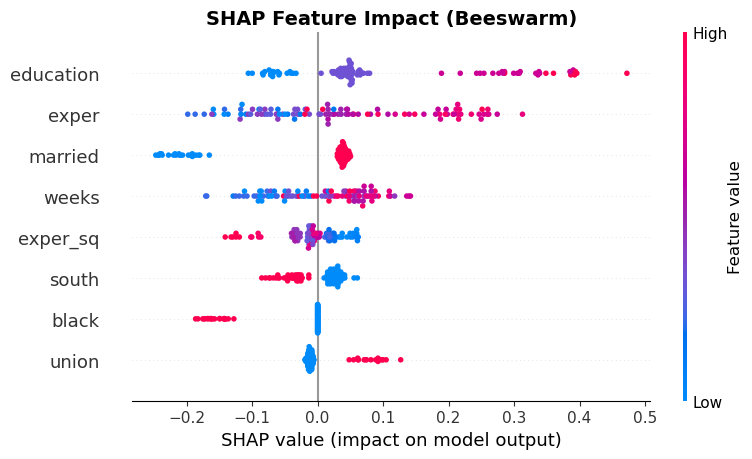

  Saved: wage_shap_beeswarm.png

[7. Visualization 3: Partial Dependence Plots]
  Creating partial dependence plots for all features...
  These show the average effect of each feature on model predictions
Saved partial dependence plots to f:\空间统计与计量方法\文章发表\SofewareX\提交版本\PanelEnsembleXGBoost\examples\shap_test_output\wage_shap_partial_dependence.png


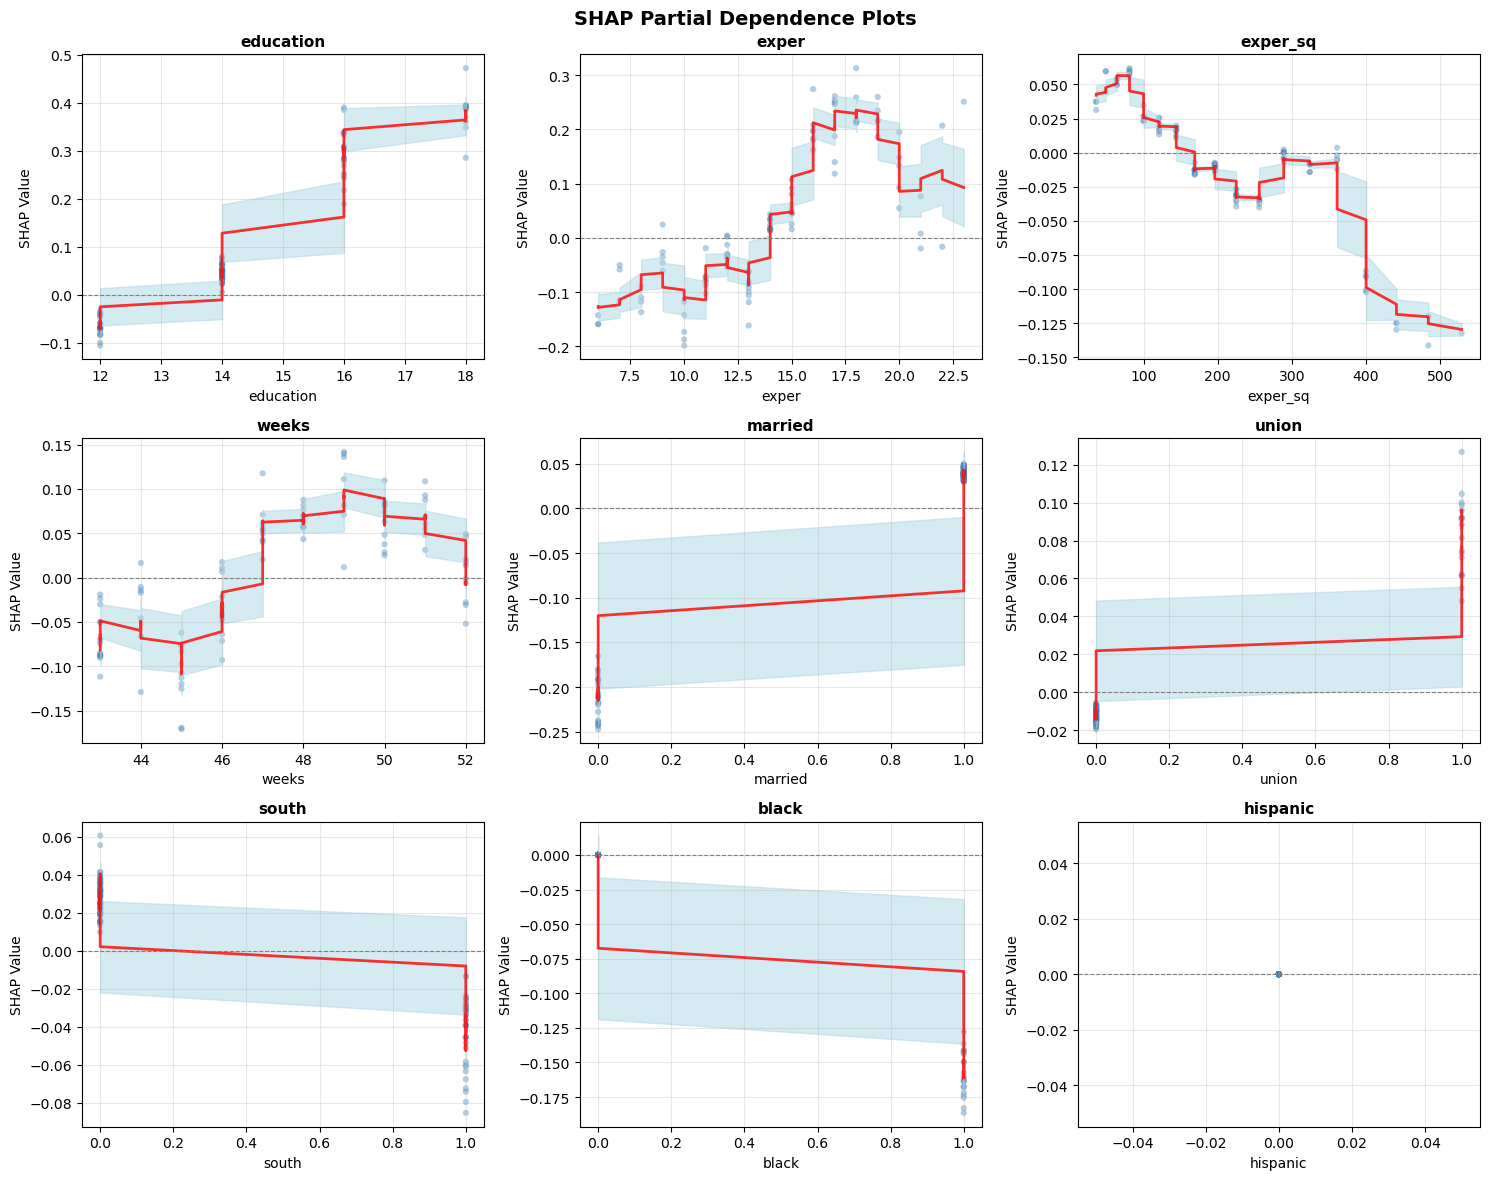

  Saved: wage_shap_partial_dependence.png

[8. Visualization 4: Waterfall Plots (Combined)]
  Creating combined waterfall plots for first 4 instances...
  Saved: wage_shap_waterfall_combined.png
Saved waterfall plot to f:\空间统计与计量方法\文章发表\SofewareX\提交版本\PanelEnsembleXGBoost\examples\shap_test_output\wage_shap_waterfall_instance0.png


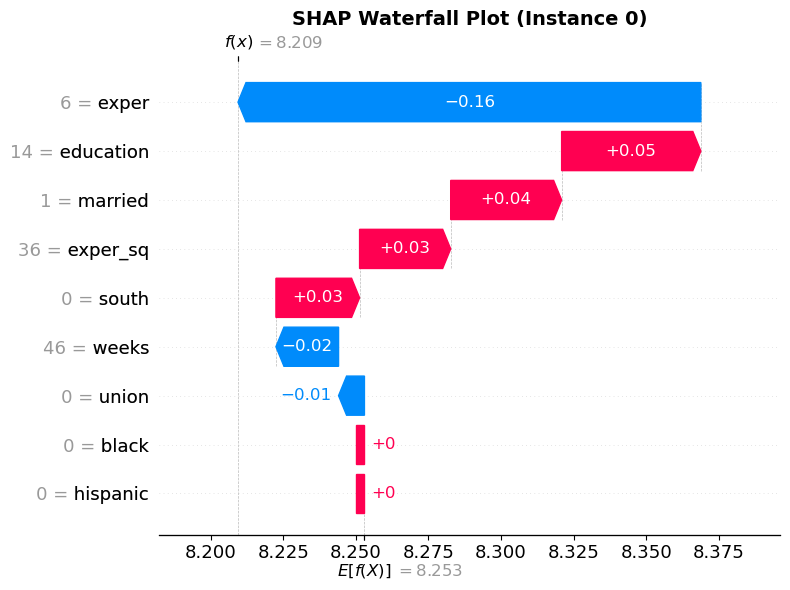

Saved waterfall plot to f:\空间统计与计量方法\文章发表\SofewareX\提交版本\PanelEnsembleXGBoost\examples\shap_test_output\wage_shap_waterfall_instance1.png


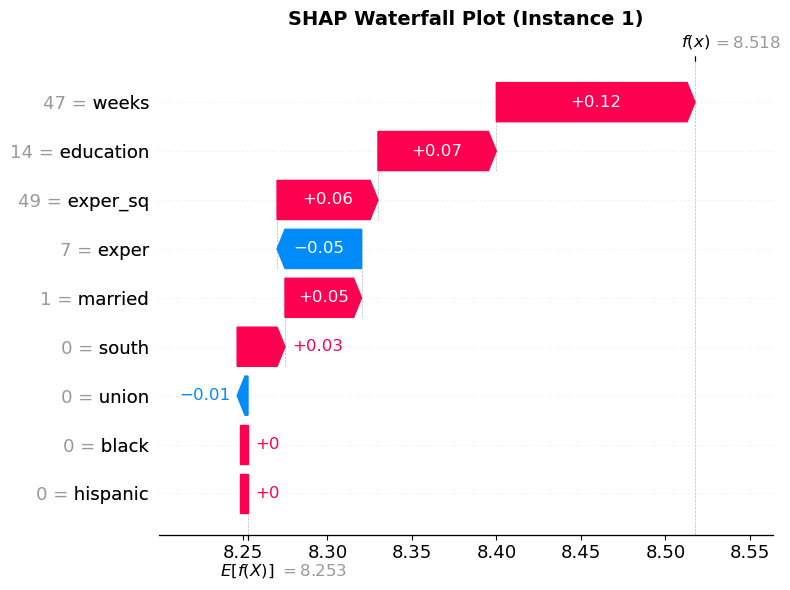

Saved waterfall plot to f:\空间统计与计量方法\文章发表\SofewareX\提交版本\PanelEnsembleXGBoost\examples\shap_test_output\wage_shap_waterfall_instance2.png


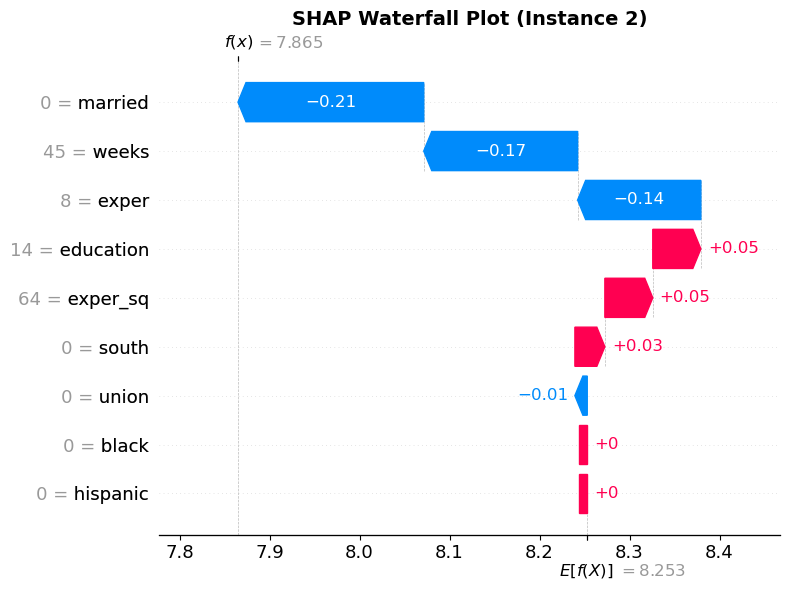

Saved waterfall plot to f:\空间统计与计量方法\文章发表\SofewareX\提交版本\PanelEnsembleXGBoost\examples\shap_test_output\wage_shap_waterfall_instance3.png


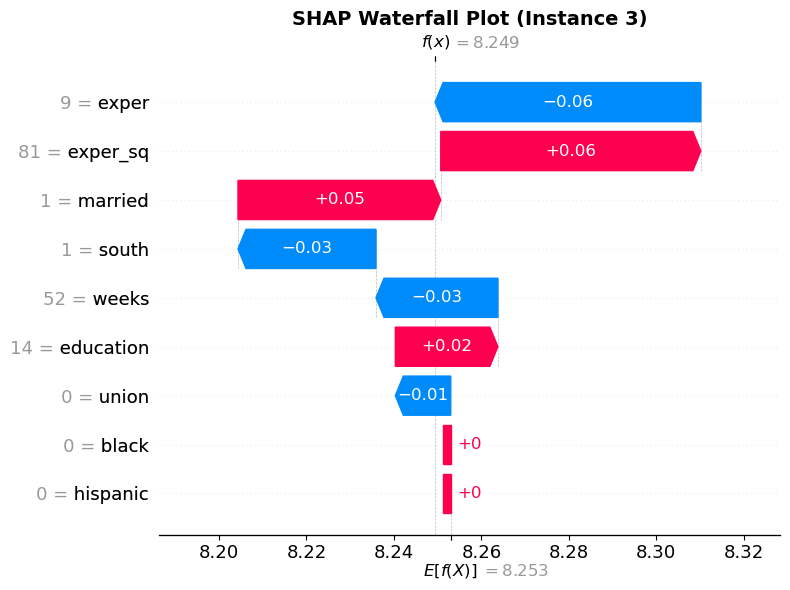


[9. Creating Combined Summary Figure]
  Combining all SHAP visualizations into one comprehensive figure...
  Saved: wage_shap_combined_summary.png
  Combined image size: 18475 x 10618 pixels

SHAP Analysis Summary

[Feature Importance Interpretation]

1. education:
   Mean |SHAP|: 0.1335
   Education level (years of schooling)
   Higher education strongly increases wage
   Effect may be nonlinear (diminishing returns at high levels)

2. exper:
   Mean |SHAP|: 0.1116
   Work experience (years)
   Experience increases wage with diminishing returns
   GAM captures the nonlinear experience-wage profile

5. married:
   Mean |SHAP|: 0.0788
   Marriage status indicator
   Married individuals tend to have higher wages
   Could reflect selection or productivity effects

4. weeks:
   Mean |SHAP|: 0.0641
   Weeks worked in year
   More weeks worked leads to higher annual wage
   May have threshold effects

3. exper_sq:
   Mean |SHAP|: 0.0331
   Feature: exper_sq
   Contribution to wage predictio

In [2]:

print("\n" + "=" * 70)
print("SHAP Analysis Test with WagePanel Data")
print("=" * 70)
print("\nThis script demonstrates:")
print("  1. WagePanel data loading and preprocessing")
print("  2. PanelEnsembleXGBoost model training")
print("  3. SHAP analysis with visualizations:")
print("     - Bar plot (feature importance)")
print("     - Beeswarm plot")
print("     - Partial dependence plots")
print("     - Waterfall plots")
    
# Load data
print("\n" + "=" * 70)
print("Step 1: Load WagePanel Data")
print("=" * 70)
    
df = load_wage_panel_data()
    
# Train model
model, X, y, groups, feature_cols = train_model(df)
    
# SHAP analysis
output_dir = os.path.join(current_dir, 'shap_test_output')
analyzer, importance = shap_analysis(model, X, y, groups, feature_cols, output_dir=output_dir)
    
print("\n" + "=" * 70)
print("Analysis Completed Successfully!")
print("=" * 70)
print(f"\nAll SHAP visualizations have been saved to: {output_dir}")
print("Check the following files:")
print("  • wage_shap_bar.png")
print("  • wage_shap_beeswarm.png")
print("  • wage_shap_partial_dependence.png")
print("  • wage_shap_waterfall_combined.png (combined waterfall plots)")
print("  • wage_shap_waterfall_instance*.png (individual waterfall plots)")
print("  • wage_shap_combined_summary.png (all visualizations combined)")
